In [1]:
import torch
from evaluation_metrics import curve_posterior_slerp_deviation, curve_false_pos, curve_true_pos
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torch.utils.data import DataLoader, TensorDataset, Subset
from utils import NestedDiagonalGMM
from geometry_tools import lerp
from pretrained_models import NestedVAE
from torch.nn.functional import cross_entropy, mse_loss
from typing import NamedTuple
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from tqdm import tqdm
from posterior_manifold import FisherLogPosteriorManifold, PullbackRiemannianManifold
from dataclasses import dataclass
from collections.abc import Callable

def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
vae = NestedVAE()

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/net/st1/export/clusterhome/robertwiebe/ml_geometry_project/pretrained_models.py:280: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torc

In [3]:
from matplotlib.ticker import MultipleLocator
def show_latent_curve(curve: torch.Tensor, title=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=(12, 1.25))
        ax = fig.add_subplot()
    with torch.no_grad():
        img = make_grid(vae.decode(curve), nrow=curve.shape[0])
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray', extent=(0, 1, 0, 1/len(curve)))
    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.xaxis.set_major_locator(MultipleLocator(0.1))
    # ax.set_xlim(0, 1)
    if title: ax.set_title(title)

attribute_names = ["5_o_Clock_Shadow", "Arched_Eyebrows", "Attractive", "Bags_Under_Eyes", "Bald", "Bangs", "Big_Lips", "Big_Nose", "Black_Hair", "Blond_Hair", "Blurry", "Brown_Hair", "Bushy_Eyebrows", "Chubby", "Double_Chin", "Eyeglasses", "Goatee", "Gray_Hair", "Heavy_Makeup", "High_Cheekbones", "Male", "Mouth_Slightly_Open", "Mustache", "Narrow_Eyes", "No_Beard", "Oval_Face", "Pale_Skin", "Pointy_Nose", "Receding_Hairline", "Rosy_Cheeks", "Sideburns", "Smiling", "Straight_Hair", "Wavy_Hair", "Wearing_Earrings", "Wearing_Hat", "Wearing_Lipstick", "Wearing_Necklace", "Wearing_Necktie", "Young"]

def show_posterior(curve: torch.Tensor, log_posterior, title=None, ax=None, top_n_labels: int | None = None):
    with torch.no_grad():
        posterior = torch.exp(log_posterior(curve.cuda()).cpu())
    if not ax:
        fig = plt.figure()
        ax = fig.add_subplot()
    if top_n_labels:
        prominence = posterior.sum(dim=0)
        order = prominence.sort(descending=True).indices
        top, others = order[:top_n_labels], order[top_n_labels:]
        ax.plot(
            posterior[:, top],
            label=[attribute_names[i] for i in top]
        )
        ax.plot(posterior[:, others], c='gray')
        ax.legend()
    else:
        ax.plot(posterior)
    if title: ax.set_title(title)

In [4]:
nested_gmm_params = torch.load('trained_checkpoints/celeba_nested_nested_gmm_4.pt')
nested_gmm = NestedDiagonalGMM(
    means=nested_gmm_params['means'],
    variances=nested_gmm_params['variances'],
    subweights=nested_gmm_params['subweights'],
    supweights=nested_gmm_params['supweights'],
)

/tmp/user/5678/ipykernel_3220218/2406645237.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nested_gmm_params = torch.load('trained_checkpoints/celeba_nested_nested_gmm_

In [5]:
M = FisherLogPosteriorManifold(nested_gmm.log_posterior)

In [6]:
class InterpolationGroup(NamedTuple):
    linline: torch.Tensor
    dec_geodesic: torch.Tensor
    ebm_geodesic: torch.Tensor
    geodesic: torch.Tensor
    labels: torch.Tensor

In [ ]:
interpolations = torch.load('pickled_objects/interpolations_new.pt')

/tmp/user/5678/ipykernel_2190309/3993778469.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  interpolations = torch.load('pickled_objects/interpolations_new.pt')


In [8]:
from attribute_prediction_model_new.model import model as attribute_model_new
attribute_model_new.load_state_dict(torch.load('attribute_prediction_model_new/checkpoints/best_checkpoint.pt')['model_state_dict'])
attribute_model_new = attribute_model_new.cuda()

/tmp/user/5678/ipykernel_2188528/1447311468.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  attribute_model_new.load_state_dict(torch.load('attribute_prediction_model_ne

In [10]:
from latent_attribute_prediction.model import MLP_ELU_convex
attribute_model = MLP_ELU_convex()
attribute_model.load_state_dict(torch.load('latent_attribute_prediction/checkpoints/best_checkpoint.pt')['model_state_dict'])
attribute_model = attribute_model.cuda()

/tmp/user/5678/ipykernel_2186526/4019763577.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  attribute_model.load_state_dict(torch.load('latent_attribute_prediction/check

In [13]:
linline, dec_geodesic, ebm_geodesic, geodesic, labels = interpolations[1]

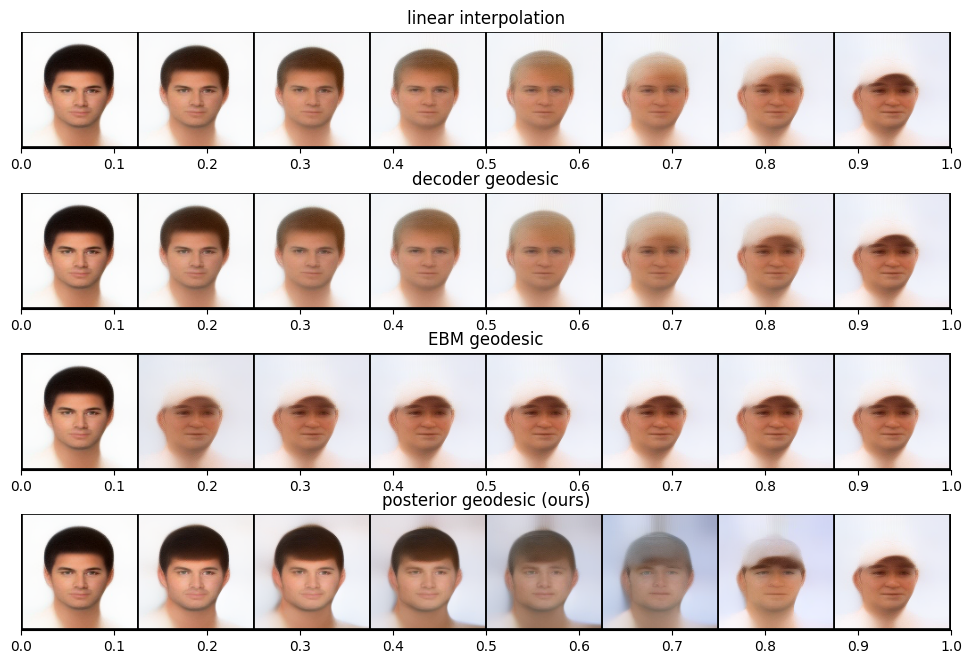

In [9]:
comp_idx = 4
linline, dec_geodesic, ebm_geodesic, geodesic, labels = interpolations[comp_idx]
_, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))
show_latent_curve(linline, 'linear interpolation', ax=ax1)
show_latent_curve(dec_geodesic, 'decoder geodesic', ax=ax2)
show_latent_curve(ebm_geodesic, 'EBM geodesic', ax=ax3)
show_latent_curve(geodesic, 'posterior geodesic (ours)', ax=ax4)
plt.show()

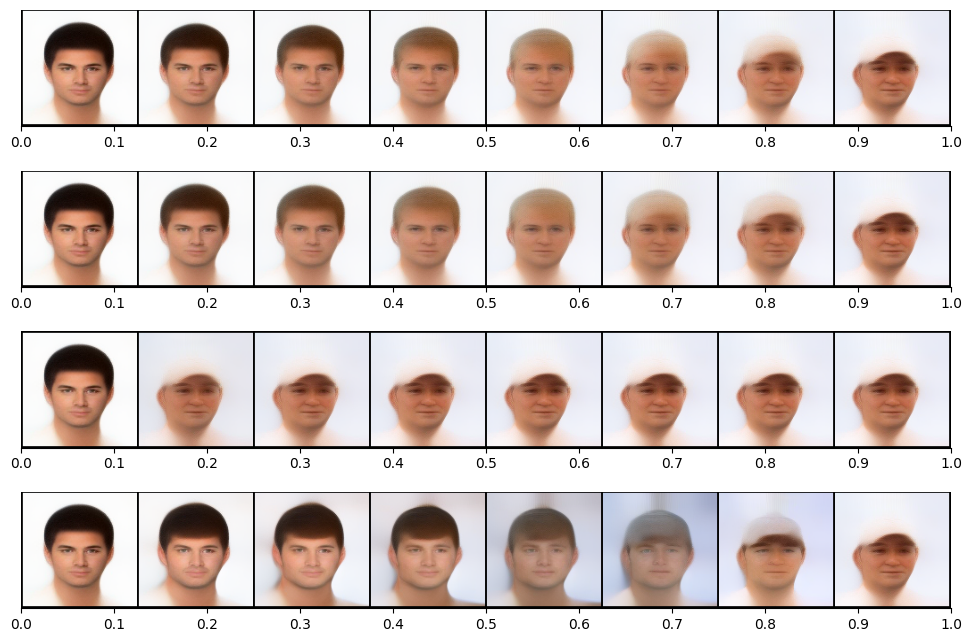

In [129]:
_, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))
show_latent_curve(linline, ax=ax1)
show_latent_curve(dec_geodesic, ax=ax2)
show_latent_curve(ebm_geodesic, ax=ax3)
show_latent_curve(geodesic, ax=ax4)
plt.savefig(f'results/4_interpolations_comp/comp_{comp_idx}.png', bbox_inches='tight')

## FID evaluation

In [6]:
LATENTS_PATH = 'datasets/celeba_deep_embeddings_w_y.pt'
best_fit_indices = torch.load('pickled_objects/top_indices_loss.pt')
X, y = torch.load(LATENTS_PATH)
dataset = Subset(TensorDataset(X, y), best_fit_indices)

/tmp/user/5678/ipykernel_3935638/3716364146.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_fit_indices = torch.load('pickled_objects/top_indices_loss.pt')
/tmp/use

In [7]:
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=4)

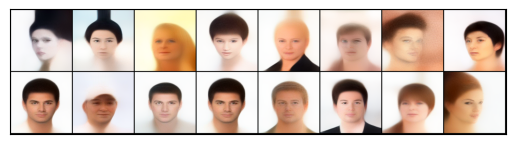

In [8]:
imgs, _ = next(iter(dataloader))
show_img(make_grid(vae.decode(imgs)))

In [25]:
fid = FrechetInceptionDistance(normalize=True, input_img_size=(3, 128, 128), reset_real_features=False)

In [32]:
fid.reset()

In [26]:
for latents, _ in tqdm(dataloader, 'Updating FID'):
    fid.update(vae.decode(latents), real=True)

Updating FID: 100%|██████████| 13/13 [00:38<00:00,  2.94s/it]


In [33]:
for _, _, _, geodesic, _ in tqdm(interpolations, 'Updating FID'):
    fid.update(vae.decode(geodesic), real=False)

Updating FID: 100%|██████████| 100/100 [02:25<00:00,  1.45s/it]


In [28]:
fid.compute() # linline

tensor(11.6199)

In [22]:
fid.compute() # dec_geodesic

tensor(13.1555)

In [31]:
fid.compute() # ebm_geodesic

tensor(4.1745)

In [34]:
fid.compute() # geodesic

tensor(15.4344)

## IS evaluation

In [16]:
inception = InceptionScore(normalize=True)
for linline, _, _, _, _ in tqdm(interpolations, 'Updating IS'):
    inception.update(vae.decode(linline))
inception.compute()

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Updating IS: 100%|██████████| 100/100 [00:27<00:00,  3.65it/s]


(tensor(2.0579), tensor(0.1077))

In [38]:
inception = InceptionScore(normalize=True)
for _, dec_geodesic, _, _, _ in tqdm(interpolations, 'Updating IS'):
    inception.update(vae.decode(dec_geodesic))
inception.compute()

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Updating IS: 100%|██████████| 100/100 [02:20<00:00,  1.40s/it]


(tensor(2.0601), tensor(0.1944))

In [39]:
inception = InceptionScore(normalize=True)
for _, _, ebm_geodesic, _, _ in tqdm(interpolations, 'Updating IS'):
    inception.update(vae.decode(ebm_geodesic))
inception.compute()

Updating IS: 100%|██████████| 100/100 [02:19<00:00,  1.39s/it]


(tensor(2.2654), tensor(0.2334))

In [40]:
inception = InceptionScore(normalize=True)
for _, _, _, geodesic, _ in tqdm(interpolations, 'Updating IS'):
    inception.update(vae.decode(geodesic))
inception.compute()

Updating IS: 100%|██████████| 100/100 [02:22<00:00,  1.42s/it]


(tensor(2.2097), tensor(0.1355))

## New IS evaluation

In [11]:
print([name for name, l in zip(attribute_names, labels[0]) if l])

['Eyeglasses', 'Mouth_Slightly_Open', 'No_Beard', 'Smiling', 'Wearing_Hat', 'Wearing_Necklace', 'Young']


In [10]:
print([name for name, l in zip(attribute_names, labels[0].bool() & labels[1].bool()) if l])

['No_Beard', 'Young']


In [19]:
target_dists = lerp(*labels, n=8)
target_dists /= target_dists.sum(dim=-1, keepdim=True)

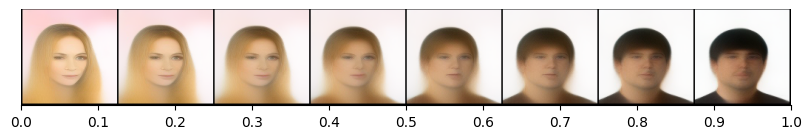

In [43]:
show_latent_curve(linline)

In [34]:
with torch.inference_mode():
    top_inds = (attribute_model(vae.decode(linline.cuda()))[0].cpu()).sort(descending=True).indices[:5]
    print([attribute_names[i] for i in top_inds])

['No_Beard', 'Young', 'Attractive', 'Oval_Face', 'Blond_Hair']


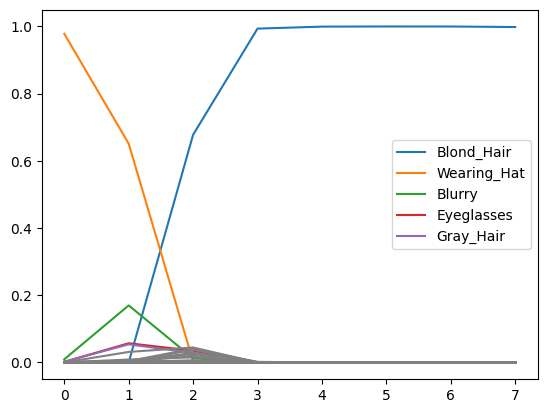

In [12]:
show_posterior(linline, nested_gmm.log_posterior, top_n_labels=5)

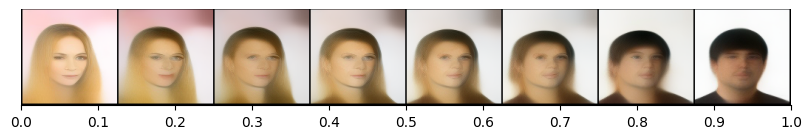

In [44]:
show_latent_curve(geodesic)

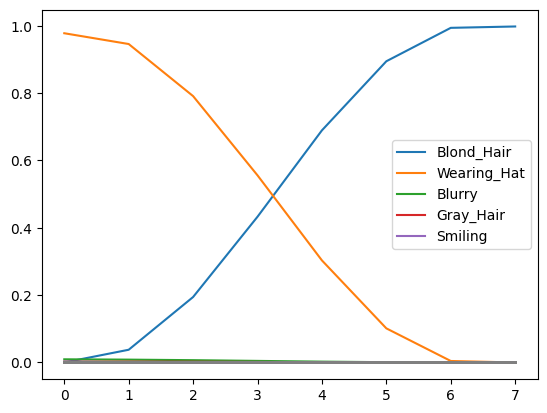

In [14]:
show_posterior(geodesic, nested_gmm.log_posterior, top_n_labels=5)

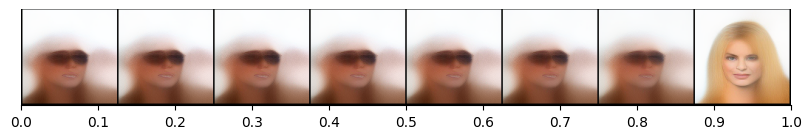

In [18]:
show_latent_curve(ebm_geodesic)

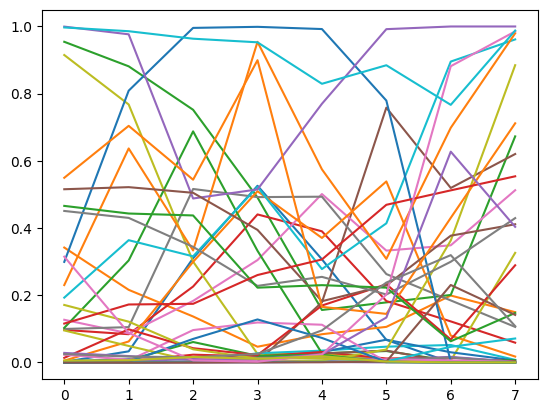

In [51]:
with torch.inference_mode():
    plt.plot(attribute_model(vae.decode(linline.cuda())).cpu())

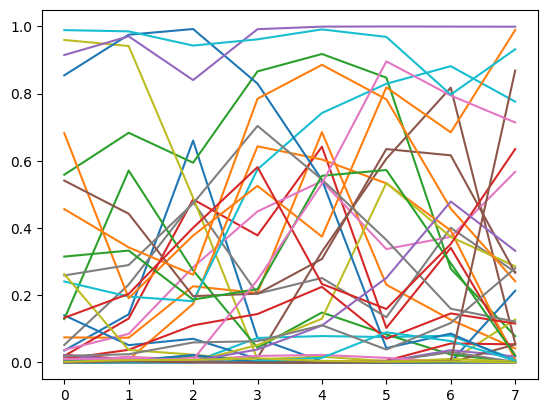

In [52]:
with torch.inference_mode():
    plt.plot(attribute_model(vae.decode(geodesic.cuda())).cpu())

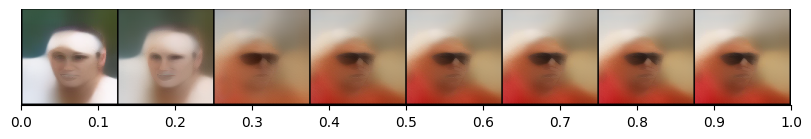

In [56]:
show_latent_curve(ebm_geodesic)

In [120]:
mse_loss(nested_gmm.posterior(linline.cuda()).cpu(), target_dists, reduction='sum')
# cross_entropy(target_dists, nested_gmm.posterior(linline.cuda()).cpu())

tensor(1.2941)

In [121]:
mse_loss(nested_gmm.posterior(geodesic.cuda()).cpu(), target_dists, reduction='sum')
# cross_entropy(target_dists, nested_gmm.posterior(geodesic.cuda()).cpu())

tensor(0.8372)

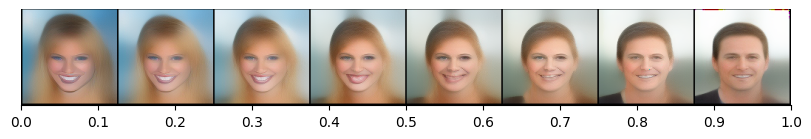

In [107]:
linline, dec_geodesic, ebm_geodesic, geodesic, labels = interpolations[45]
target_dists = lerp(*labels, n=8)
target_dists /= target_dists.sum(dim=-1, keepdim=True)
show_latent_curve(geodesic)

In [114]:
with torch.no_grad():
    print(vae.decode(linline[1]).mean())

tensor(0.5574)


In [98]:
for i, (linl, *_) in enumerate(interpolations[30:]):
    with torch.no_grad():
        if vae.decode(linl[0]).mean() >= .5 and vae.decode(linl[-1]).mean() >= .5:
            print(i)
            break

14


In [14]:
curve_posterior_slerp_deviation(linline.cuda(), nested_gmm.posterior).cpu()

tensor(1.6816)

In [15]:
curve_posterior_slerp_deviation(geodesic.cuda(), nested_gmm.posterior).cpu()

tensor(0.0180)

In [53]:
linline, dec_geodesic, ebm_geodesic, geodesic, labels = interpolations[24]

In [22]:
with torch.inference_mode():
    print("True positive")
    print("Linline: ", curve_true_pos(linline.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
    print("Geodesic: ", curve_true_pos(geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())

True positive
Linline:  tensor(15.6641)
Geodesic:  tensor(15.0546)


In [23]:
with torch.no_grad():
    print("False positive")
    print("Linline: ", curve_false_pos(linline.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
    print("Geodesic: ", curve_false_pos(geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())

False positive
Linline:  tensor(50.3988)
Geodesic:  tensor(52.1829)


In [53]:
with torch.inference_mode():
    print("Attribute prediction fluctuation")
    lin_att = attribute_model(vae.decode(linline.cuda())).cpu()
    geo_att = attribute_model(vae.decode(geodesic.cuda())).cpu()
    print("Linline: ", (lin_att[1:] - lin_att[:-1]).square().mean())
    print("Geodesic: ", (geo_att[1:] - geo_att[:-1]).square().mean())

Attribute prediction fluctuation
Linline:  tensor(0.0299)
Geodesic:  tensor(0.0327)


In [ ]:
with torch.inference_mode():
    print("True positive")
    print("Linline: ", curve_true_pos(linline.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
    print("Geodesic: ", curve_true_pos(geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())

In [ ]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.no_grad():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        target_dists = lerp(*labels, n=8)
        target_dists /= target_dists.sum(dim=-1, keepdim=True)
        lin_vals_list.append(mse_loss(nested_gmm.posterior(linline.cuda()).cpu(), target_dists, reduction='sum'))
        dec_vals_list.append(mse_loss(nested_gmm.posterior(dec_geodesic.cuda()).cpu(), target_dists, reduction='sum'))
        ebm_vals_list.append(mse_loss(nested_gmm.posterior(ebm_geodesic.cuda()).cpu(), target_dists, reduction='sum'))
        geo_vals_list.append(mse_loss(nested_gmm.posterior(geodesic.cuda()).cpu(), target_dists, reduction='sum'))

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for true postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 515.46it/s]

--- Final results for true postive score---

Linear interpolation: 1.7810 ± 1.0226
Decoder geodesic:     1.7739 ± 1.0202
EBM geodesic:         2.3381 ± 1.4255
Posterior geodesic:   1.5219 ± 1.0634


In [125]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.no_grad():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        target_dists = lerp(*labels, n=8)
        target_dists /= target_dists.sum(dim=-1, keepdim=True)
        lin_vals_list.append(cross_entropy(target_dists, nested_gmm.posterior(linline.cuda()).cpu(), reduction='sum'))
        dec_vals_list.append(cross_entropy(target_dists, nested_gmm.posterior(dec_geodesic.cuda()).cpu(), reduction='sum'))
        ebm_vals_list.append(cross_entropy(target_dists, nested_gmm.posterior(ebm_geodesic.cuda()).cpu(), reduction='sum'))
        geo_vals_list.append(cross_entropy(target_dists, nested_gmm.posterior(geodesic.cuda()).cpu(), reduction='sum'))

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for true postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 244.62it/s]

--- Final results for true postive score---

Linear interpolation: 29.2175 ± 0.1149
Decoder geodesic:     29.2164 ± 0.1130
EBM geodesic:         29.2329 ± 0.1308
Posterior geodesic:   29.2278 ± 0.1313


In [ ]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
    lin_vals_list.append(curve_posterior_slerp_deviation(linline.cuda(), nested_gmm.posterior).cpu())
    dec_vals_list.append(curve_posterior_slerp_deviation(dec_geodesic.cuda(), nested_gmm.posterior).cpu())
    ebm_vals_list.append(curve_posterior_slerp_deviation(ebm_geodesic.cuda(), nested_gmm.posterior).cpu())
    geo_vals_list.append(curve_posterior_slerp_deviation(geodesic.cuda(), nested_gmm.posterior).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 371.41it/s]


In [25]:
print("--- Final results for posterior slerp deviation---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

--- Final results for posterior slerp deviation---

Linear interpolation: 0.9352 ± 0.5480
Decoder geodesic:     0.9431 ± 0.5673
EBM geodesic:         0.9275 ± 0.5593
Posterior geodesic:   0.0313 ± 0.0330


In [56]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.inference_mode():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        target_dists = lerp(*labels, n=8)
        target_dists /= target_dists.sum(dim=-1, keepdim=True)
        lin_vals_list.append(curve_false_pos(linline.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        dec_vals_list.append(curve_false_pos(dec_geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        ebm_vals_list.append(curve_false_pos(ebm_geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        geo_vals_list.append(curve_false_pos(geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for false postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:37<00:00,  2.65it/s]

--- Final results for false postive score---

Linear interpolation: 44.0072 ± 3.5310
Decoder geodesic:     44.0405 ± 3.3993
EBM geodesic:         43.2072 ± 4.4031
Posterior geodesic:   43.7655 ± 3.7981


In [61]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.inference_mode():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        target_dists = lerp(*labels, n=8)
        target_dists /= target_dists.sum(dim=-1, keepdim=True)
        lin_vals_list.append(curve_true_pos(linline.cuda(), attribute_model, labels[0].cuda(), labels[1].cuda()).cpu())
        dec_vals_list.append(curve_true_pos(dec_geodesic.cuda(), attribute_model, labels[0].cuda(), labels[1].cuda()).cpu())
        ebm_vals_list.append(curve_true_pos(ebm_geodesic.cuda(), attribute_model, labels[0].cuda(), labels[1].cuda()).cpu())
        geo_vals_list.append(curve_true_pos(geodesic.cuda(), attribute_model, labels[0].cuda(), labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for true postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 564.50it/s]

--- Final results for true postive score---

Linear interpolation: 11.8044 ± 6.2208
Decoder geodesic:     11.7964 ± 6.2208
EBM geodesic:         11.7556 ± 6.1327
Posterior geodesic:   11.8060 ± 6.2243


In [62]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.inference_mode():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        target_dists = lerp(*labels, n=8)
        target_dists /= target_dists.sum(dim=-1, keepdim=True)
        lin_vals_list.append(curve_false_pos(linline.cuda(), attribute_model, labels[0].cuda(), labels[1].cuda()).cpu())
        dec_vals_list.append(curve_false_pos(dec_geodesic.cuda(), attribute_model, labels[0].cuda(), labels[1].cuda()).cpu())
        ebm_vals_list.append(curve_false_pos(ebm_geodesic.cuda(), attribute_model, labels[0].cuda(), labels[1].cuda()).cpu())
        geo_vals_list.append(curve_false_pos(geodesic.cuda(), attribute_model, labels[0].cuda(), labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for false postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 562.88it/s]

--- Final results for false postive score---

Linear interpolation: 44.4638 ± 9.2971
Decoder geodesic:     44.1426 ± 9.2348
EBM geodesic:         47.3435 ± 9.8841
Posterior geodesic:   41.0372 ± 10.3480


### w/ new attribute prediction model

In [ ]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.inference_mode():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        target_dists = lerp(*labels, n=8)
        target_dists /= target_dists.sum(dim=-1, keepdim=True)
        lin_vals_list.append(curve_true_pos(linline.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        dec_vals_list.append(curve_true_pos(dec_geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        ebm_vals_list.append(curve_true_pos(ebm_geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        geo_vals_list.append(curve_true_pos(geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for true postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:38<00:00,  2.59it/s]

--- Final results for false postive score---

Linear interpolation: 9.8788 ± 4.9844
Decoder geodesic:     9.8841 ± 4.9966
EBM geodesic:         9.9374 ± 4.9554
Posterior geodesic:   9.9001 ± 5.0113


In [55]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.inference_mode():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        target_dists = lerp(*labels, n=8)
        target_dists /= target_dists.sum(dim=-1, keepdim=True)
        lin_vals_list.append(curve_false_pos(linline.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        dec_vals_list.append(curve_false_pos(dec_geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        ebm_vals_list.append(curve_false_pos(ebm_geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        geo_vals_list.append(curve_false_pos(geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for false postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:38<00:00,  2.57it/s]

--- Final results for false postive score---

Linear interpolation: 52.3088 ± 5.2128
Decoder geodesic:     52.3728 ± 5.0760
EBM geodesic:         52.4053 ± 6.2261
Posterior geodesic:   52.0679 ± 5.3702


# Running the evaluation and collecting results

### Posterior slerp deviation

In [15]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
    lin_vals_list.append(curve_posterior_slerp_deviation(linline.cuda(), nested_gmm.posterior).cpu())
    dec_vals_list.append(curve_posterior_slerp_deviation(dec_geodesic.cuda(), nested_gmm.posterior).cpu())
    ebm_vals_list.append(curve_posterior_slerp_deviation(ebm_geodesic.cuda(), nested_gmm.posterior).cpu())
    geo_vals_list.append(curve_posterior_slerp_deviation(geodesic.cuda(), nested_gmm.posterior).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for posterior slerp deviation---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 346.18it/s]

--- Final results for posterior slerp deviation---

Linear interpolation: 1.2494 ± 0.8898
Decoder geodesic:     1.2504 ± 0.9087
EBM geodesic:         1.5260 ± 0.9507
Posterior geodesic:   0.0164 ± 0.0215


### True positive score

In [13]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.no_grad():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        lin_vals_list.append(curve_true_pos(linline.cuda(), nested_gmm.posterior, labels[0].cuda(), labels[1].cuda()).cpu())
        dec_vals_list.append(curve_true_pos(dec_geodesic.cuda(), nested_gmm.posterior, labels[0].cuda(), labels[1].cuda()).cpu())
        ebm_vals_list.append(curve_true_pos(ebm_geodesic.cuda(), nested_gmm.posterior, labels[0].cuda(), labels[1].cuda()).cpu())
        geo_vals_list.append(curve_true_pos(geodesic.cuda(), nested_gmm.posterior, labels[0].cuda(), labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for true postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 452.46it/s]

--- Final results for true postive score---

Linear interpolation: 2.9137 ± 2.4377
Decoder geodesic:     2.9149 ± 2.4508
EBM geodesic:         2.9622 ± 2.6274
Posterior geodesic:   3.3033 ± 2.6466


### False positive score

In [14]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.no_grad():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        lin_vals_list.append(curve_false_pos(linline.cuda(), nested_gmm.posterior, labels[0].cuda(), labels[1].cuda()).cpu())
        dec_vals_list.append(curve_false_pos(dec_geodesic.cuda(), nested_gmm.posterior, labels[0].cuda(), labels[1].cuda()).cpu())
        ebm_vals_list.append(curve_false_pos(ebm_geodesic.cuda(), nested_gmm.posterior, labels[0].cuda(), labels[1].cuda()).cpu())
        geo_vals_list.append(curve_false_pos(geodesic.cuda(), nested_gmm.posterior, labels[0].cuda(), labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for false negative score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 463.60it/s]

--- Final results for false negative score---

Linear interpolation: 2.2275 ± 1.3205
Decoder geodesic:     2.2284 ± 1.3223
EBM geodesic:         1.5894 ± 1.1206
Posterior geodesic:   1.2051 ± 0.8794


### Old stuff

In [8]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.no_grad():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        lin_vals_list.append(curve_true_pos(linline.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        dec_vals_list.append(curve_true_pos(dec_geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        ebm_vals_list.append(curve_true_pos(ebm_geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        geo_vals_list.append(curve_true_pos(geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for true postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:38<00:00,  2.60it/s]

--- Final results for true postive score---

Linear interpolation: 15.1339 ± 8.1439
Decoder geodesic:     15.0906 ± 8.1073
EBM geodesic:         15.4496 ± 8.3017
Posterior geodesic:   15.0328 ± 8.1124


In [9]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.no_grad():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        lin_vals_list.append(curve_false_pos(linline.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        dec_vals_list.append(curve_false_pos(dec_geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        ebm_vals_list.append(curve_false_pos(ebm_geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())
        geo_vals_list.append(curve_false_pos(geodesic.cuda(), lambda x: attribute_model(vae.decode(x)), labels[0].cuda(), labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for true postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:38<00:00,  2.61it/s]

--- Final results for true postive score---

Linear interpolation: 20.7211 ± 7.2485
Decoder geodesic:     20.6836 ± 7.2087
EBM geodesic:         19.9637 ± 7.7360
Posterior geodesic:   20.5693 ± 7.0013


In [16]:
likelihoods = lambda x: nested_gmm.dist.component_distribution.log_prob(x[..., None, :])

In [17]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.no_grad():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        lin_vals_list.append(curve_true_pos(linline.cuda(), likelihoods,  labels[0].cuda(), labels[1].cuda()).cpu())
        dec_vals_list.append(curve_true_pos(dec_geodesic.cuda(), likelihoods, labels[0].cuda(), labels[1].cuda()).cpu())
        ebm_vals_list.append(curve_true_pos(ebm_geodesic.cuda(), likelihoods, labels[0].cuda(), labels[1].cuda()).cpu())
        geo_vals_list.append(curve_true_pos(geodesic.cuda(), likelihoods, labels[0].cuda(), labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for true postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 505.73it/s]


--- Final results for true postive score---

Linear interpolation: -2069.1057 ± 1217.1239
Decoder geodesic:     -2062.6235 ± 1213.0194
EBM geodesic:         -2126.1179 ± 1216.2448
Posterior geodesic:   -2331.7886 ± 1380.7969


In [18]:
lin_vals_list, dec_vals_list, ebm_vals_list, geo_vals_list = [], [], [], []

with torch.no_grad():
    for linline, dec_geodesic, ebm_geodesic, geodesic, labels in tqdm(interpolations, 'Running evaluation'):
        lin_vals_list.append(curve_false_pos(linline.cuda(), likelihoods,  labels[0].cuda(), labels[1].cuda()).cpu())
        dec_vals_list.append(curve_false_pos(dec_geodesic.cuda(), likelihoods, labels[0].cuda(), labels[1].cuda()).cpu())
        ebm_vals_list.append(curve_false_pos(ebm_geodesic.cuda(), likelihoods, labels[0].cuda(), labels[1].cuda()).cpu())
        geo_vals_list.append(curve_false_pos(geodesic.cuda(), likelihoods, labels[0].cuda(), labels[1].cuda()).cpu())

lin_vals = np.array(lin_vals_list)
dec_vals = np.array(dec_vals_list)
ebm_vals = np.array(ebm_vals_list)
geo_vals = np.array(geo_vals_list)

print("--- Final results for true postive score---", end="\n\n")
print(f"Linear interpolation: {lin_vals.mean():.4f} ± {lin_vals.std():.4f}")
print(f"Decoder geodesic:     {dec_vals.mean():.4f} ± {dec_vals.std():.4f}")
print(f"EBM geodesic:         {ebm_vals.mean():.4f} ± {ebm_vals.std():.4f}")
print(f"Posterior geodesic:   {geo_vals.mean():.4f} ± {geo_vals.std():.4f}")

Running evaluation: 100%|██████████| 100/100 [00:00<00:00, 519.31it/s]

--- Final results for true postive score---

Linear interpolation: -15992.5996 ± 2264.6279
Decoder geodesic:     -15931.1445 ± 2255.3928
EBM geodesic:         -16573.0430 ± 2376.3062
Posterior geodesic:   -17780.6484 ± 2856.2244


## Seeing what happens when interpolating based on discriminative attribute prediction model

In [11]:
@dataclass
class EuclidianPullbackmanifold(PullbackRiemannianManifold):
    coordinate_transform: Callable[[torch.Tensor], torch.Tensor]
    def coordinate_map(self, coords: torch.Tensor) -> torch.Tensor:
        return self.coordinate_transform(coords)
M_attr_latent = EuclidianPullbackmanifold(lambda x: attribute_model(x))
M_attr_outer = EuclidianPullbackmanifold(lambda x: attribute_model_new(vae.decode(x)))

optimizing geodesic: 100%|██████████| 10000/10000 [00:53<00:00, 187.79it/s, loss=0.199]


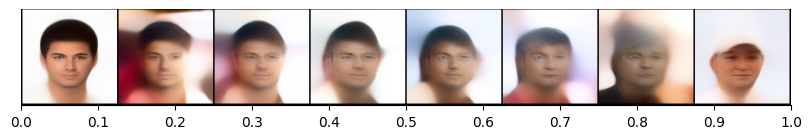

In [ ]:
endpoint_latents = linline[[0, -1]]
interp_latent = M_attr_latent.optimize_geodesic(*endpoint_latents, n_segments=8, n_iter=10000, n_subdiv=3)
show_latent_curve(interp_latent)

optimizing geodesic: 100%|██████████| 100/100 [01:41<00:00,  1.01s/it, loss=2.48]


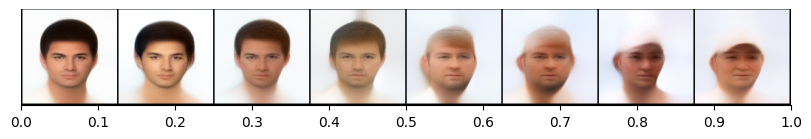

In [15]:
endpoint_latents = linline[[0, -1]]
interp_outer = M_attr_outer.optimize_geodesic(*endpoint_latents, n_segments=8, n_iter=100, n_subdiv=3, lr=0.1)
show_latent_curve(interp_outer)

In [19]:
interp_outer.requires_grad

False